# 03 · Finding and driving the qubit

Part 2 found the readout resonator. That tells you where to point the readout tone and nothing at all about the qubit. A transmon sitting at 4.85 GHz leaves no mark on a 7.2 GHz transmission scan.

This part closes the gap and then calibrates a gate. Two-tone spectroscopy finds `f01` by driving the qubit with a second tone while the readout watches the resonator. Rabi in amplitude turns that frequency into a pi pulse. A `WaveformLibrary` holds the pulse so later programs can name it instead of inlining its amplitude. The flux arc then maps `f01` against a DC bias, and it is the first experiment in this tutorial whose outer loop cannot run on a sequencer.

Each experiment consumes the answer the one before it produced, and that is how a bring-up actually runs. Every fit prints its value next to the true one, because the device is simulated and you can check your own work.

In [1]:
# Run me first. A no-op when qprogram is already installed, an install when it is not
# (a fresh Google Colab runtime, for example).
try:
    import qprogram  # noqa: F401
except ImportError:
    import subprocess
    import sys

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "qprogram[viz]==0.1.0", "scipy"],
        check=True,
    )
    import qprogram  # noqa: F401

from importlib.metadata import version

print("qprogram", version("qprogram"))

qprogram 0.1.0


In [2]:
from dataclasses import replace

import matplotlib.pyplot as plt
import numpy as np
import scipy
from scipy.optimize import curve_fit

import qprogram as qp
from qprogram import MeasurementField as MF
from qprogram.buses import BusSchema
from qprogram.plotting import DEFAULT_SIZE, LIGHT, Quantity, Style
from qprogram.waveforms import IQDrag, IQPair, Square

print("numpy", np.__version__, "| scipy", scipy.__version__, "(curve_fit does every fit below)")

numpy 2.5.2 | scipy 1.18.1 (curve_fit does every fit below)


## 3.0 The device under test

`DEVICE` holds the truth about the simulated chip. The measurement models read it because they play the part of the fridge, and the print statements read it to grade the fits. The programs use exactly one number from it, `q0_fr`, and only because Part 2 measured that one already. Everything else they have to find out. A real experiment does not know these numbers, so neither does the code that would run on hardware.

Part 2 also left two waveforms behind, the readout pulse and the integration weights. The programs below ask for them by name, as the strings `"readout"` and `"weights"`, and the library in 3.3 is where the objects go.

In [3]:
DEVICE = {
    "q0_f01": 4.85e9,  # Hz, qubit transition at the flux sweet spot
    "q0_fr": 7.20e9,  # Hz, readout resonator (found in Part 2)
    "q0_kappa": 1.5e6,  # Hz, resonator linewidth (FWHM)
    "q0_chi": -1.8e6,  # Hz, dispersive shift
    "q0_a_pi": 0.62,  # drive amplitude of a pi pulse (DAC units)
    "q0_linewidth": 2.0e6,  # Hz, spectroscopy FWHM at low power
    "flux_period": 1.0,  # V, one flux quantum in bias volts
    "flux_offset": 0.05,  # V, where the sweet spot actually sits
}

schema = BusSchema.transmon()
q = schema.q

READOUT_PULSE = IQPair(I=Square(amplitude=0.2, duration=2000), Q=Square(amplitude=0.0, duration=2000))
WEIGHTS = IQPair(I=Square(amplitude=1.0, duration=2000), Q=Square(amplitude=1.0, duration=2000))

print("drive bus  :", q[0].drive, "channel:", q[0].drive.channel)
print("readout bus:", q[0].readout, "acquires:", q[0].readout.acquires)
print("readout pulse:", READOUT_PULSE.get_duration(), "ns")
print("target to recover: f01 =", DEVICE["q0_f01"] / 1e9, "GHz")

drive bus  : q0/drive channel: IQ
readout bus: q0/readout acquires: True
readout pulse: 2000 ns
target to recover: f01 = 4.85 GHz


## 3.1 Two-tone spectroscopy

Nothing you send down the readout line at 7.2 GHz touches something sitting at 4.85 GHz, and the drive line has no ADC, so the qubit is only ever seen through the resonator. Running two tones at once is the way around that.

1. Park the readout tone on the resonator, where Part 2 put it, and keep it there.
2. Send a second tone down the **drive** line and sweep its frequency across the band where the qubit ought to be.
3. When the second tone hits $f_{01}$ the qubit gets excited and the resonator, coupled to it, shifts by $2\chi$ = 3.6 MHz. Against a 1.5 MHz linewidth that is a large move, so the readout tone that was sitting in the dip is suddenly off it and the transmission you measure jumps.

Read that chain backwards and you have the reason the resonator had to come first. The signal is not the qubit. It is the resonator changing its mind about where it lives, and you cannot notice that unless you were already parked in the right place.

The drive pulse for this scan is 4 microseconds at 2 percent of full scale, and both numbers are deliberate. Weak, because the amplitude of a pi pulse is the thing this part exists to produce, so a clean flip is not yet available to you. What a weak tone can do instead is saturate the transition and hold the population at a steady value, which for a two-level system tops out at 0.5. The model below returns 0.45 at resonance for that reason, and a two-tone peak above 0.5 is a readout calibration error rather than a very excited qubit. Long, because that steady state has to be reached before the readout looks, and at these Rabi rates the transition saturates in well under a microsecond.

The window is 20 MHz wide, so this scan assumes you already know `f01` to roughly that much, from the chip design, from a cooldown last month, or from a wide survey scan like the flux arc in 3.4. A weak tone leaves the line near its 2 MHz low-power width, and the 250 kHz step then puts eight points across it. Part 1 wrote down where that 2 MHz comes from, the 35 kHz coherence linewidth of a 9 us $T_2^*$, power-broadened by the very tone you are using to see it.

The drive bus is an IQ channel, so the saturation tone is an `IQPair`. A bare `Square` on that bus raises a `ValidationError` at build time.

In [4]:
SATURATION = IQPair(
    I=Square(amplitude=0.02, duration=4000),  # 4 us at 2% of full scale
    Q=Square(amplitude=0.0, duration=4000),
)


def p_spec(bus, env):
    """Excited-state population under a long weak drive: a Lorentzian peak at f01."""
    hwhm = DEVICE["q0_linewidth"] / 2
    return 0.45 / (1.0 + ((env["drive_freq"] - DEVICE["q0_f01"]) / hwhm) ** 2)


print("on resonance :", round(p_spec(None, {"drive_freq": DEVICE["q0_f01"]}), 4))
print("2 MHz off    :", round(p_spec(None, {"drive_freq": DEVICE["q0_f01"] + 2e6}), 4))
print("20 MHz off   :", round(p_spec(None, {"drive_freq": DEVICE["q0_f01"] + 20e6}), 4))

on resonance : 0.45
2 MHz off    : 0.09
20 MHz off   : 0.0011


### Asking for the state field

Part 2 read `iq`, the integrated readout point, because a resonator scan is about transmission. Here the quantity of interest is the qubit population, so the measurement asks for a different field:

```python
program.measure(bus, "readout", "weights", fields=(MF.STATE,))
```

`fields=` is a request to the platform. Produce classified single-shot outcomes for this measurement, not just the integrated point. Three things follow from it.

- `average(shots)` adds no dimension. Averaging 200 single-shot zeros and ones gives you the excited-state population directly, as a float between 0 and 1.
- The scatter on that population is binomial, not instrumental. Averaging $N$ classified shots of an outcome that comes up excited with probability $p$ has a standard error of $\sqrt{p(1-p)/N}$, about 0.035 at the top of this peak with 200 shots. Nothing is added by hand. The `noise=` argument of `MockMeasurementModel` perturbs the IQ point rather than the classified outcome, so the models in this notebook do not pass it.
- You read it back with `result.get(handle, field=MF.STATE)`, and you draw it with `result.plot(handle, field=MF.STATE)`. A bare `result.get(handle)` defaults to `iq` and raises `KeyError` here, because this measurement never asked for `iq`.

On real hardware the classifier needs its own calibration, and Part 4 does that with single shots. In the simulator the `p_excited` callback of `MockMeasurementModel` supplies the probability and the model draws the shots.

In [5]:
spec = qp.QProgram(
    label="qubit_spectroscopy",
    description="Two-tone scan for f01 on q0",
    schema=schema,
)
drive_freq = spec.variable("drive_freq", label="Drive frequency", units="Hz")

# 81 points x 200 shots = 16k interpreted shots, well under a second.
with spec.average(shots=200):
    with spec.sweep(drive_freq, qp.Linspace(4.840e9, 4.860e9, 81)):
        spec.set_frequency(q[0].readout, DEVICE["q0_fr"])  # park the readout on the resonator
        spec.set_frequency(q[0].drive, drive_freq)  # the tone we are sweeping
        spec.play(q[0].drive, SATURATION)
        spec.sync()  # on hardware, hold the readout until the drive finishes
        m_spec = spec.measure(q[0].readout, "readout", "weights", fields=(MF.STATE,))

print("variables :", [v.id for v in spec.variables])
print("handle    :", m_spec.name)
print("sweep step:", (4.860e9 - 4.840e9) / 80 / 1e6, "MHz")
print()
print(qp.dumps(spec))

variables : ['drive_freq']
handle    : q0/readout/m0
sweep step: 0.25 MHz

#!QProgram 1.0

metadata:
  label: "qubit_spectroscopy"
  description: "Two-tone scan for f01 on q0"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires

body:
  var drive_freq label="Drive frequency" units="Hz"

  average 200:
    for drive_freq in Linspace(start=4840000000.0, stop=4860000000.0, num=81):
      set_frequency q[0].readout 7200000000.0
      set_frequency q[0].drive drive_freq
      play q[0].drive IQPair(I=Square(amplitude=0.02, duration=4000), Q=Square(amplitude=0.0, duration=4000))
      sync
      measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state"]



Two details in that text worth a second look. The readout pulse and weights are still the strings `"readout"` and `"weights"`, because nothing in this experiment depends on their shape. And `fields=["state"]` is on the measure line, so the file records what the experiment asked the hardware to produce.

The `label` and `units` on `drive_freq` do a second job the moment the result comes back. Both ride along on the coordinate, so the x axis of the next figure names itself and you never type an axis label again. Declare them on every variable you sweep. Hertz is still the wrong scale for reading a 20 MHz window, and `Quantity` is how the figure says gigahertz without the stored array moving.

dims: ('drive_freq',) shape: (81,)


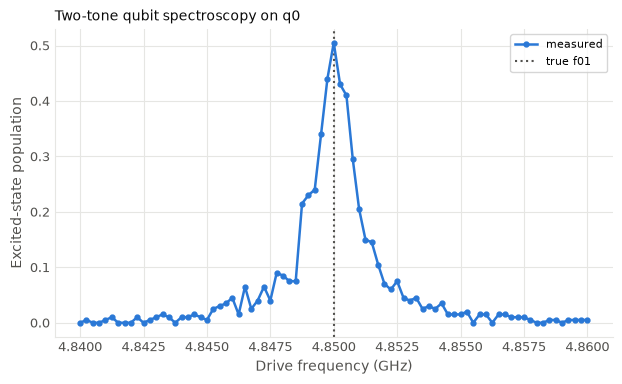

In [6]:
model = qp.MockMeasurementModel(p_excited=p_spec,  seed=11)
result = qp.simulate(spec, model=model)

pop = result.get(m_spec, field=MF.STATE)
print("dims:", pop.dims, "shape:", pop.shape)

spec_freqs = pop.coords["drive_freq"].values
spec_pop = pop.values

# Two restatements every figure below reuses. The array stays in hertz; only the drawing moves.
GHZ = Quantity(units="GHz", transform=lambda v: v / 1e9)
POPULATION = Quantity("Excited-state population")

ax = result.plot(
    m_spec,
    field=MF.STATE,
    style=Style(markers=True),  # 81 coarse points: the samples are the measurement
    coords={"drive_freq": GHZ},
    value=POPULATION,  # the state field would otherwise label itself "State"
    title="Two-tone qubit spectroscopy on q0",
)
ax.lines[0].set_label("measured")
ax.axvline(DEVICE["q0_f01"] / 1e9, color=LIGHT.muted, linestyle=":", label="true f01")
ax.legend(fontsize=8)
plt.show()

### Fitting the peak

The highest point in the scan is a poor estimate of `f01`. It can only ever be as accurate as your step size, and with 250 kHz steps and binomial scatter of 0.035 on every point it will land on the wrong grid point often enough to matter. A fit uses all 81 points at once, so the uncertainty falls roughly as the linewidth over the signal-to-noise times the square root of the point count, and it comes with an error bar you can quote.

The peak is a Lorentzian:

$$P(f) = P_0 + \frac{A}{1 + \left(\dfrac{f - f_{01}}{\gamma}\right)^2}$$

with $\gamma$ the half width at half maximum, so the linewidth you would quote in a paper is $2\gamma$. Four free parameters, and `curve_fit` wants a starting guess for each. Read them off the data. The peak position from `argmax`, the height from the range, the width from your prior (a few megahertz), and the floor from the median.

Starting guesses matter more than they look. `curve_fit` is a local optimizer, so a Lorentzian started three linewidths away from the peak sees a flat landscape and stays where it was put. Every guess below is read off the data rather than typed in, and that habit keeps a fit working when the qubit moves overnight.

In [7]:
def lorentzian(f, f0, height, hwhm, floor):
    """Lorentzian peak, parameterised the way a spectroscopist reads it off a plot."""
    return floor + height / (1.0 + ((f - f0) / hwhm) ** 2)


guess = (
    spec_freqs[spec_pop.argmax()],  # centre
    spec_pop.max() - np.median(spec_pop),  # height
    1e6,  # HWHM, order of magnitude is enough
    float(np.median(spec_pop)),  # floor
)
spec_fit, spec_cov = curve_fit(lorentzian, spec_freqs, spec_pop, p0=guess)
f01_fit, height_fit, hwhm_fit, floor_fit = spec_fit
f01_sigma = float(np.sqrt(np.diag(spec_cov))[0])

print(f"argmax    : {spec_freqs[spec_pop.argmax()] / 1e9:.6f} GHz  (grid step 0.250 MHz)")
print(f"fitted    : {f01_fit / 1e9:.6f} GHz  +/- {f01_sigma / 1e6:.3f} MHz")
print(f"true      : {DEVICE['q0_f01'] / 1e9:.6f} GHz")
print(f"error     : {(f01_fit - DEVICE['q0_f01']) / 1e6:+.3f} MHz")
print(f"linewidth : {2 * abs(hwhm_fit) / 1e6:.3f} MHz fitted vs {DEVICE['q0_linewidth'] / 1e6:.3f} MHz true")

argmax    : 4.850000 GHz  (grid step 0.250 MHz)
fitted    : 4.850038 GHz  +/- 0.016 MHz
true      : 4.850000 GHz
error     : +0.038 MHz
linewidth : 1.768 MHz fitted vs 2.000 MHz true


Draw the fit on top of the data and one rule of the plotting API starts to matter. `GHZ` moved the numbers on the axis rather than the tick labels, so the axes the call returns is in gigahertz and everything you add to it has to arrive in gigahertz too. The fit was computed in hertz, so it gets divided by `1e9` on the way in, and so does each reference line. The colours come out of `LIGHT`, the theme the measurement was drawn with, so an overlay does not turn up in a palette of its own.

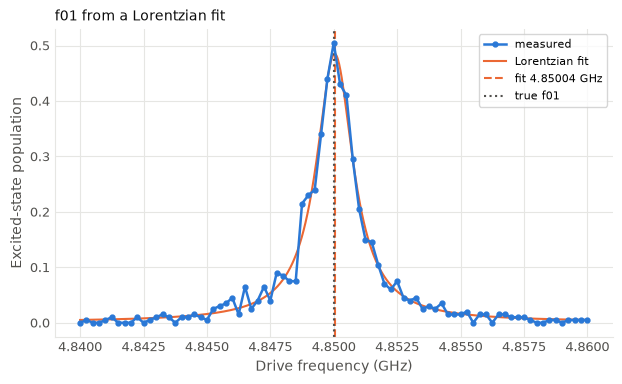

In [8]:
dense = np.linspace(spec_freqs[0], spec_freqs[-1], 800)

ax = result.plot(
    m_spec,
    field=MF.STATE,
    style=Style(markers=True),
    coords={"drive_freq": GHZ},
    value=POPULATION,
    title="f01 from a Lorentzian fit",
)
ax.lines[0].set_label("measured")
ax.plot(dense / 1e9, lorentzian(dense, *spec_fit), color=LIGHT.series[1], label="Lorentzian fit")
ax.axvline(f01_fit / 1e9, color=LIGHT.series[1], linestyle="--", label=f"fit {f01_fit / 1e9:.5f} GHz")
ax.axvline(DEVICE["q0_f01"] / 1e9, color=LIGHT.muted, linestyle=":", label="true f01")
ax.legend(fontsize=8)
plt.show()

## 3.2 Rabi: how hard to hit it

You now know where the qubit is, to a fifth of a linewidth. The next question is how much amplitude a 40 ns pulse needs to rotate the state by $\pi$, and the scan that answers it starts by setting the drive to the frequency you just fitted.

The physics is one line. A resonant drive rotates the Bloch vector about an axis in the equatorial plane at a rate set by the drive amplitude, so with the shape and the duration held fixed the angle turned is proportional to the amplitude. The excited-state population after a rotation by $\theta$ is $\sin^2(\theta/2)$, so sweeping amplitude sweeps you through $\theta = \pi$ and the population traces a $\sin^2$ whose first maximum is the pi pulse. The ceiling is 1 here rather than the 0.45 of the scan above, because a coherent rotation can put everything in $|1\rangle$ and a saturated transition cannot. Two scans, two different maxima, and the peak height alone tells you which one you are looking at.

**Why sweep amplitude rather than duration.** Both produce an oscillation and both are used. An amplitude sweep keeps the envelope shape fixed, so the spectral content of the pulse does not change as you move along the axis, and it is a continuous knob with 14 or 16 bits behind it. A duration sweep changes the shape, and it is quantised to the sample clock, so at 40 ns your step size is a few percent of the answer. Amplitude is the knob you calibrate with. Duration is the one you sweep when you are studying the pulse itself.

Two things in the program are new. The pulse is an `IQDrag`, the standard single-qubit envelope on a transmon, a Gaussian on I with its scaled derivative on Q, and Part 1 has the full story on why the derivative is there. And the swept variable goes **inside the waveform**:

```python
program.play(q[0].drive, IQDrag(amplitude=amp, duration=40, sigma=10, beta=0.1))
```

`amp` is a `Variable`, not a number. Every waveform parameter accepts an `Expression`, so the pulse is parametric and the loop binds it. The `.qp` text keeps the variable name, so the file records the sweep rather than 41 hard-coded pulses.

In [9]:
def p_rabi(bus, env):
    """Rabi oscillation in amplitude: a full pi rotation at DEVICE['q0_a_pi']."""
    return np.sin(np.pi * env["amp"] / (2 * DEVICE["q0_a_pi"])) ** 2


rabi = qp.QProgram(label="rabi_amplitude", description="Amplitude Rabi on q0", schema=schema)
amp = rabi.variable("amp", label="Drive amplitude", units="DAC units")

with rabi.average(shots=200):
    with rabi.sweep(amp, qp.Linspace(0.0, 1.0, 41)):
        rabi.set_frequency(q[0].drive, f01_fit)  # the fitted frequency, not the true one
        rabi.play(q[0].drive, IQDrag(amplitude=amp, duration=40, sigma=10, beta=0.1))
        rabi.sync()
        m_rabi = rabi.measure(q[0].readout, "readout", "weights", fields=(MF.STATE,))

print(qp.dumps(rabi))

#!QProgram 1.0

metadata:
  label: "rabi_amplitude"
  description: "Amplitude Rabi on q0"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires

body:
  var amp label="Drive amplitude" units="DAC units"

  average 200:
    for amp in Linspace(start=0.0, stop=1.0, num=41):
      set_frequency q[0].drive 4850037623.644008
      play q[0].drive IQDrag(amplitude=amp, duration=40, sigma=10, beta=0.1)
      sync
      measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state"]



dims: ('amp',) shape: (41,)
highest measured point at amplitude 0.575
(a noisy estimate of the pi amplitude; the fit below uses every point)


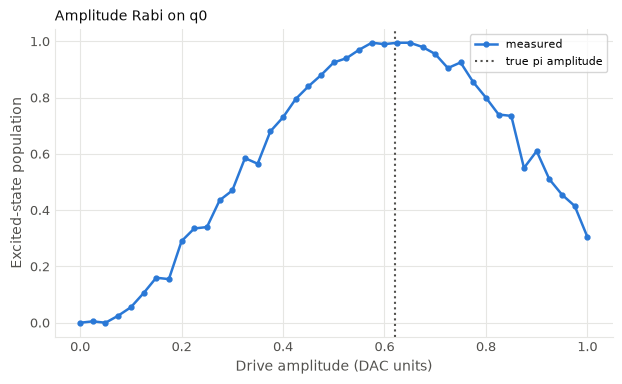

In [10]:
rabi_result = qp.simulate(rabi, model=qp.MockMeasurementModel(p_excited=p_rabi,  seed=17))
rabi_data = rabi_result.get(m_rabi, field=MF.STATE)

rabi_amps = rabi_data.coords["amp"].values
rabi_pop = rabi_data.values
print("dims:", rabi_data.dims, "shape:", rabi_data.shape)
print("highest measured point at amplitude", round(float(rabi_amps[rabi_pop.argmax()]), 4))
print("(a noisy estimate of the pi amplitude; the fit below uses every point)")

# The amplitude axis carries no unit change, so this figure needs no coords= at all.
ax = rabi_result.plot(
    m_rabi,
    field=MF.STATE,
    style=Style(markers=True),
    value=POPULATION,
    title="Amplitude Rabi on q0",
)
ax.lines[0].set_label("measured")
ax.axvline(DEVICE["q0_a_pi"], color=LIGHT.muted, linestyle=":", label="true pi amplitude")
ax.legend(fontsize=8)
plt.show()

### Fitting the pi amplitude

The curve is

$$P(a) = P_0 + C \sin^2\!\left(\frac{\pi a}{2 a_\pi}\right)$$

so $a_\pi$ is the amplitude at the first maximum. Fitting for it directly, rather than fitting a generic sinusoid and converting afterwards, means `curve_fit` reports the uncertainty on the number you actually want. Do that deliberately every time. Write the model in terms of the calibration parameter.

$C$ is the readout contrast and $P_0$ the floor, and neither is a nuisance parameter. On a real device the floor sits above zero because the qubit is not perfectly cold and because the classifier sometimes calls a $|0\rangle$ a $|1\rangle$; the contrast falls below one for the same reasons in reverse, plus whatever relaxes during the readout window. A floor that creeps up over a week means the fridge or the classifier is drifting. A contrast that collapses overnight usually means the readout tone moved, not that the qubit did. Both are the cheapest health checks you own, and they come free with a fit you were running anyway.

One refinement worth knowing about, because this fit is only the first pass. The precision on $a_\pi$ is limited by how sharply the curve turns over at its maximum, and a $\sin^2$ is flat there. The standard next step is to play the pi pulse an odd number of times, say 21, and sweep the amplitude again. An error $\epsilon$ per pulse becomes $21\epsilon$ in the measured angle, and the same scan resolves the amplitude 21 times better. Every lab has that experiment, and it needs nothing this tutorial has not already shown you.

In [11]:
def rabi_model(a, a_pi, contrast, floor):
    """Rabi in amplitude, parameterised by the pi amplitude itself."""
    return floor + contrast * np.sin(np.pi * a / (2 * a_pi)) ** 2


rabi_fit, rabi_cov = curve_fit(
    rabi_model,
    rabi_amps,
    rabi_pop,
    p0=(rabi_amps[rabi_pop.argmax()], rabi_pop.max() - rabi_pop.min(), rabi_pop.min()),
)
a_pi_fit, contrast_fit, floor_fit = rabi_fit
a_pi_sigma = float(np.sqrt(np.diag(rabi_cov))[0])

print(f"a_pi fitted : {a_pi_fit:.4f} +/- {a_pi_sigma:.4f}")
print(f"a_pi true   : {DEVICE['q0_a_pi']:.4f}")
print(f"error       : {100 * (a_pi_fit - DEVICE['q0_a_pi']) / DEVICE['q0_a_pi']:+.2f}%")
print(f"contrast    : {contrast_fit:.3f}   floor: {floor_fit:.3f}")

a_pi fitted : 0.6176 +/- 0.0022
a_pi true   : 0.6200
error       : -0.39%
contrast    : 0.998   floor: 0.006


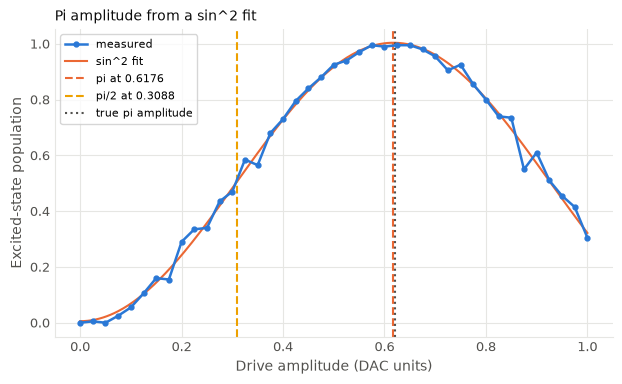

In [12]:
dense_amp = np.linspace(rabi_amps[0], rabi_amps[-1], 400)

ax = rabi_result.plot(
    m_rabi,
    field=MF.STATE,
    style=Style(markers=True),
    value=POPULATION,
    title="Pi amplitude from a sin^2 fit",
)
ax.lines[0].set_label("measured")
ax.plot(dense_amp, rabi_model(dense_amp, *rabi_fit), color=LIGHT.series[1], label="sin^2 fit")
ax.axvline(a_pi_fit, color=LIGHT.series[1], linestyle="--", label=f"pi at {a_pi_fit:.4f}")
ax.axvline(a_pi_fit / 2, color=LIGHT.series[3], linestyle="--", label=f"pi/2 at {a_pi_fit / 2:.4f}")
ax.axvline(DEVICE["q0_a_pi"], color=LIGHT.muted, linestyle=":", label="true pi amplitude")
ax.legend(fontsize=8)
plt.show()

### The calibrated pulses

A calibrated gate, in this stack, is a waveform object with numbers in it. Nothing more.

`PI_PULSE` flips the qubit. `X90_PULSE` takes it to the equator and is the workhorse of Part 4, where Ramsey needs two of them and the echo needs two with a pi pulse in between. Both are plain `IQDrag` instances, so they compare by structure. Two pulses are equal when every parameter matches. A calibration set is diffable for that reason, and it is also why an amplitude gets rounded before it goes into a file. The fit above knows this amplitude to about 0.002, so four decimals is already finer than the measurement and it keeps the text readable.

Halving `a_pi` for the x90 assumes the response is exactly $\sin^2$. On this simulated chip it is, by construction. On a real one it is not quite, because the DAC and the amplifier chain are not perfectly linear and because a shorter effective rotation samples the pulse envelope differently. Exercise 3.1 measures the pi/2 amplitude instead of assuming it, and comparing the two numbers is how you find out whether your drive line is linear over the range you care about.

An `IQWaveform` draws itself on two stacked panels, one per quadrature, and `plot()` hands back that `(I, Q)` pair. Give the pair to a second call as `target=` and both pulses land on the same two panels. The second call also gets a rotated palette, because the theme hands out its colours in order and two calls in a row would otherwise draw the x90 in the pi pulse's hues.

pi  : 0.6176 over 40 ns
x90 : 0.3088 over 40 ns
structural equality: True
a different beta is a different pulse: False


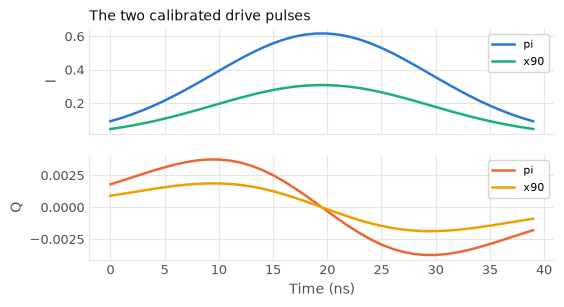

In [13]:
PI_PULSE = IQDrag(amplitude=round(float(a_pi_fit), 4), duration=40, sigma=10, beta=0.1)
X90_PULSE = IQDrag(amplitude=round(float(a_pi_fit) / 2, 4), duration=40, sigma=10, beta=0.1)

print("pi  :", PI_PULSE.amplitude, "over", PI_PULSE.get_duration(), "ns")
print("x90 :", X90_PULSE.amplitude, "over", X90_PULSE.get_duration(), "ns")
print("structural equality:", PI_PULSE == IQDrag(PI_PULSE.amplitude, 40, 10, 0.1))
print("a different beta is a different pulse:", PI_PULSE == IQDrag(PI_PULSE.amplitude, 40, 10, 0.2))

ax_i, ax_q = PI_PULSE.plot()
rotated = Style(theme=replace(LIGHT, series=LIGHT.series[2:] + LIGHT.series[:2]))
X90_PULSE.plot(target=(ax_i, ax_q), style=rotated)

for panel in (ax_i, ax_q):
    for line, name in zip(panel.lines, ("pi", "x90"), strict=True):
        line.set_label(name)
    panel.legend(fontsize=8)
ax_i.set_title("The two calibrated drive pulses", loc="left", fontsize=10, pad=6)
plt.show()

### 🧩 Exercise 3.1: fit the x90 amplitude instead of halving

Rather than trusting $a_\pi / 2$, measure it. Refit **only the rising branch** of the Rabi curve (everything up to the maximum) with the model written in terms of $a_{90}$:

$$P(a) = P_0 + C \sin^2\!\left(\frac{\pi a}{4 a_{90}}\right)$$

At $a = a_{90}$ the sine argument is $\pi/4$ and the population is halfway up, which is exactly the definition of a $\pi/2$ rotation.

Print the fitted $a_{90}$, the halved $a_\pi$ from the full fit, and the true $a_\pi / 2$ from `DEVICE`. You have `rabi_amps`, `rabi_pop`, `a_pi_fit`, `contrast_fit`, and `floor_fit` in scope. The point of the exercise is the comparison at the end. A number you assumed and a number you measured are not the same number, and on a real drive line they can differ by percent.

In [ ]:
# TODO: fit the pi/2 amplitude from the rising branch of the Rabi curve.
# 1) rising = slice(0, int(rabi_pop.argmax()) + 1)
# 2) def x90_model(a, a_90, contrast, floor): return floor + contrast * sin(pi * a / (4 * a_90))**2
# 3) curve_fit(x90_model, rabi_amps[rising], rabi_pop[rising], p0=(a_pi_fit / 2, contrast_fit, floor_fit))
# 4) print the fitted a_90, a_pi_fit / 2, and DEVICE["q0_a_pi"] / 2 side by side.

## 3.3 The calibration seam

Look at what just happened to the experiment code. The Rabi program has `IQDrag(amplitude=amp, ...)` baked into it, and that was right, because the pulse shape *is* the experiment. But every program that comes after it wants "the pi pulse", whatever today's number happens to be. If each one inlines 0.6176, then recalibrating means editing every file, and a file from six months ago silently claims a calibration it never had.

QProgram splits the two. Where a waveform is expected you may write a **string alias**, and the program is then a statement about structure with a hole in it:

```python
program.play(q[0].drive, "pi")
```

The alias survives serialization, so the `.qp` file says `play q[0].drive "pi"`. Filling the hole is a separate step, `program.with_waveforms(...)`, which returns a new program with the names resolved. The original is untouched.

The reference platform never looks at a waveform, so an unbound alias costs nothing there. Every `measure` in this notebook can name `"readout"` and `"weights"` and still run because of it. A real platform has to turn the name into samples, so off the simulator the binding step is not optional.

In [15]:
seq = qp.QProgram(label="pi_then_read", description="Flip q0 and read it out", schema=schema)

with seq.average(shots=200):
    seq.play(q[0].drive, "pi")
    seq.sync()
    m_seq = seq.measure(q[0].readout, "readout", "weights", fields=(MF.STATE,))

print(qp.dumps(seq))

#!QProgram 1.0

metadata:
  label: "pi_then_read"
  description: "Flip q0 and read it out"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires

body:
  average 200:
    play q[0].drive "pi"
    sync
    measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state"]



A `WaveformLibrary` is where the numbers live. It resolves a name **per bus**, in three tiers:

| Tier | How you register it | Matches |
|---|---|---|
| exact | `element=`, `idx=`, `kind=` | one bus |
| family | `element=`, `kind=` | every index of that element and kind |
| global | no keywords | every bus |

The tiers exist because different parts of a calibration have different scopes, and a plain dictionary flattens that distinction into one namespace. Drive pulses belong in the exact tier, because `q[0]` and `q[1]` do not share a pi amplitude and never will. Readout pulses are often a family default, since a chip's resonators are usually driven with the same shape at the same power and only the frequency differs. Integration weights are frequently global. Section 5.7 returns to this when the library has to survive a move to another rack.

In [16]:
library = qp.WaveformLibrary()
library.set("pi", PI_PULSE, element="q", idx=0, kind="drive")  # exact: this qubit only
library.set("x90", X90_PULSE, element="q", idx=0, kind="drive")
library.set("readout", READOUT_PULSE, element="q", kind="readout")  # family: any q readout
library.set("weights", WEIGHTS)  # global

bound = seq.with_waveforms(library)

print(qp.dumps(bound))
print("bound body differs from the original:", seq.body != bound.body)

#!QProgram 1.0

metadata:
  label: "pi_then_read"
  description: "Flip q0 and read it out"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires

body:
  average 200:
    play q[0].drive IQDrag(amplitude=0.6176, duration=40, sigma=10, beta=0.1)
    sync
    measure q[0].readout IQPair(I=Square(amplitude=0.2, duration=2000), Q=Square(amplitude=0.0, duration=2000)) IQPair(I=Square(amplitude=1.0, duration=2000), Q=Square(amplitude=1.0, duration=2000)) name="q0/readout/m0" fields=["state"]

bound body differs from the original: True


One name, three buses, and the tiers decide what each one gets. Give the neighbour its own exact entry and watch `"pi"` resolve to two different amplitudes in the same program.

In [17]:
library.set("pi", IQDrag(amplitude=0.55, duration=40, sigma=10, beta=0.1),
            element="q", idx=1, kind="drive")  # exact: a standing calibration, not measured here

three = qp.QProgram(label="three_buses", schema=schema)
for i in (0, 1, 2):
    three.play(q[i].drive, "pi")
    three.measure(q[i].readout, "readout", "weights", fields=(MF.STATE,))

for line in qp.dumps(three.with_waveforms(library)).splitlines():
    if line.strip().startswith(("play", "measure")):
        print(line.strip()[:98])

play q[0].drive IQDrag(amplitude=0.6176, duration=40, sigma=10, beta=0.1)
measure q[0].readout IQPair(I=Square(amplitude=0.2, duration=2000), Q=Square(amplitude=0.0, durati
play q[1].drive IQDrag(amplitude=0.55, duration=40, sigma=10, beta=0.1)
measure q[1].readout IQPair(I=Square(amplitude=0.2, duration=2000), Q=Square(amplitude=0.0, durati
play q[2].drive "pi"
measure q[2].readout IQPair(I=Square(amplitude=0.2, duration=2000), Q=Square(amplitude=0.0, durati


`q[0]` and `q[1]` each have an exact entry, so the same alias becomes two different pulses. All three readouts come from the one family entry, and a family entry exists for exactly that. `q[2]` has no `pi` at any tier, so the alias survives the bind as the string it was rather than raising, and the thing that will complain is the platform that needs samples to upload. A plain dictionary would resolve one name one way everywhere, and that is the reason the library exists.

Binding costs you something, and the output above shows it plainly. The `measure` line now carries two full `IQPair` constructors. That is the trade. An aliased file is short and reviewable but means nothing without its library; a bound file is self-contained but unreadable and out of date the moment you recalibrate.

The library has its own text format, `.wfl`, and it stays outside the `.qp` file on purpose. The program is the experiment you designed. The library is the state of the fridge this morning. Those two things change on completely different schedules, and a lab that keeps them in one file ends up unable to answer "was this the same experiment?" across a recalibration.

The cell below makes the failure concrete. The same program, bound to last week's library and to today's, is two different pulses and one unchanged file on disk. If those numbers had been inlined, the only record that anything moved would be your memory.

In [18]:
print(library.dumps())

stale = qp.WaveformLibrary()
stale.set("pi", IQDrag(amplitude=0.50, duration=40, sigma=10, beta=0.1), element="q", idx=0, kind="drive")


def play_line(program):
    """Pull the single `play` statement out of a program's .qp text."""
    return next(line.strip() for line in qp.dumps(program).splitlines() if line.strip().startswith("play"))


print("bound to last week's library:", play_line(seq.with_waveforms(stale)))
print("bound to today's library    :", play_line(bound))
print("the program on disk         :", play_line(seq))

#!WaveformLibrary 1.0
"pi" q[0].drive = IQDrag(amplitude=0.6176, duration=40, sigma=10, beta=0.1)
"x90" q[0].drive = IQDrag(amplitude=0.3088, duration=40, sigma=10, beta=0.1)
"readout" q[*].readout = IQPair(I=Square(amplitude=0.2, duration=2000), Q=Square(amplitude=0.0, duration=2000))
"weights" = IQPair(I=Square(amplitude=1.0, duration=2000), Q=Square(amplitude=1.0, duration=2000))
"pi" q[1].drive = IQDrag(amplitude=0.55, duration=40, sigma=10, beta=0.1)

bound to last week's library: play q[0].drive IQDrag(amplitude=0.5, duration=40, sigma=10, beta=0.1)
bound to today's library    : play q[0].drive IQDrag(amplitude=0.6176, duration=40, sigma=10, beta=0.1)
the program on disk         : play q[0].drive "pi"


## 3.4 The flux arc

A flux-tunable transmon has a third line. A DC bias threads flux through a SQUID loop on the chip and moves `f01`. The loop's Josephson energy follows a cosine of that flux and the transmon frequency follows the square root of the energy, so the curve you measure is a square root of a cosine:

$$f_{01}(V) = f_{\max} \sqrt{\left| \cos \frac{\pi (V - V_0)}{V_\Phi} \right|}$$

Three numbers in that expression are yours to measure, and the units explain why. Your DAC puts out volts, not flux quanta, and the volts reach the loop through a mutual inductance nobody wrote down, so $V_\Phi$ is the bias interval that threads one flux quantum and it comes out of a fit. $V_0$ is the bias where the loop sees zero flux, and it is not zero volts, because the fridge has an ambient field and because the neighbouring qubits' flux lines couple into this loop too. On this simulated chip $V_0$ is 0.05 V. On a real one it moves every cooldown.

$V_0$ is the flat top of the arc, and it is the number you actually want. Park the qubit there and first-order flux noise stops moving its frequency, so $T_2^*$ is at its maximum. Every coherence number in Part 4 was measured with the qubit sitting at $V_0$.

You find it by repeating the spectroscopy of 3.1 at a series of biases, which makes the scan two dimensional. Bias on the outer loop, drive frequency on the inner one. Two changes to the program.

`BusSchema.flux_tunable_transmon()` adds `q[i].flux`, a **single**-channel bus with no ADC. Single channel means single-channel waveforms, `Square` rather than `IQPair`. Try it the other way and the builder raises before you get near an instrument.

`set_offset(bus, value)` writes a DC level rather than playing a pulse. A bias line wants exactly that. The value is the swept variable, so the outer loop is a sequence of DC writes.

Six presets ship. `transmon`, `flux_tunable_transmon`, and `fluxonium`, each with a `_coupled` variant that adds a second element `c` for the tunable couplers between qubits. A coupler is indexed by the pair it sits between, so `c[0, 1].flux` is one bus and its resolved name joins the pair with an underscore. When none of the six fits, `add_element` on a bare `BusSchema()` registers an element at run time, at the cost of the typed accessors a preset gives you.

In [19]:
flux_schema = BusSchema.flux_tunable_transmon()
qf = flux_schema.q

print("flux bus:", qf[0].flux, "channel:", qf[0].flux.channel, "acquires:", qf[0].flux.acquires)

coupled = BusSchema.flux_tunable_transmon_coupled()
print("coupler bus:", coupled.c[0, 1].flux, "channel:", coupled.c[0, 1].flux.channel)


def f01_of_bias(bias):
    """Where the qubit sits at a given flux bias. Maximum at DEVICE['flux_offset']."""
    phase = np.pi * (bias - DEVICE["flux_offset"]) / DEVICE["flux_period"]
    return DEVICE["q0_f01"] * np.sqrt(np.abs(np.cos(phase)))


POWER_BROADENED = 20e6  # Hz FWHM: this scan drives hard, so the line is much wider than 2 MHz


def p_arc(bus, env):
    """Spectroscopy peak that follows the arc as the bias steps."""
    hwhm = POWER_BROADENED / 2
    return 0.45 / (1.0 + ((env["arc_freq"] - f01_of_bias(env["bias"])) / hwhm) ** 2)


for bias_v in (-0.15, 0.05, 0.25):
    print(f"bias {bias_v:+.2f} V -> f01 {f01_of_bias(bias_v) / 1e9:.4f} GHz")

flux bus: q0/flux channel: single acquires: False
coupler bus: c0_1/flux channel: single
bias -0.15 V -> f01 4.3624 GHz
bias +0.05 V -> f01 4.8500 GHz
bias +0.25 V -> f01 4.3624 GHz


On the frequency grid: 25 bias points times 61 frequency points times 50 shots is 76k interpreted shots, a little over a second. The frequency step is about 10 MHz, which would step straight over a 2 MHz line. The model uses a 20 MHz power-broadened width for that reason, and it is not a cheat. A flux arc is a survey scan. You drive it hard on purpose so the peak is wider than your grid, find the ridge to within a step or two, and then go back with a narrow low-power scan at the one bias you care about. Trying to survey a 600 MHz band at 2 MHz resolution would need 300 columns instead of 61, and every one of them would be measuring nothing.

Shots drop from 200 to 50 for the same reason. A 2D map has to show you a ridge, not measure a population to three digits, and 50 shots gives you binomial scatter of 0.07 on a peak of 0.45. Plenty to see a bright line against a dark background.

In [20]:
arc = qp.QProgram(label="flux_arc", description="f01 against flux bias on q0", schema=flux_schema)
bias = arc.variable("bias", label="Flux bias", units="V")
arc_freq = arc.variable("arc_freq", label="Drive frequency", units="Hz")

with arc.average(shots=50):
    with arc.sweep(bias, qp.Linspace(-0.15, 0.25, 25)):
        arc.set_offset(qf[0].flux, bias)  # a DC write, not a pulse
        with arc.sweep(arc_freq, qp.Linspace(4.30e9, 4.90e9, 61)):
            arc.set_frequency(qf[0].drive, arc_freq)
            arc.play(qf[0].drive, SATURATION)
            arc.sync()
            m_arc = arc.measure(qf[0].readout, "readout", "weights", fields=(MF.STATE,))

print(qp.dumps(arc))

#!QProgram 1.0

metadata:
  label: "flux_arc"
  description: "f01 against flux bias on q0"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires
    flux info=single

body:
  var bias label="Flux bias" units="V"
  var arc_freq label="Drive frequency" units="Hz"

  average 50:
    for bias in Linspace(start=-0.15, stop=0.25, num=25):
      set_offset q[0].flux bias
      for arc_freq in Linspace(start=4300000000.0, stop=4900000000.0, num=61):
        set_frequency q[0].drive arc_freq
        play q[0].drive IQPair(I=Square(amplitude=0.02, duration=4000), Q=Square(amplitude=0.0, duration=4000))
        sync
        measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state"]



In [21]:
arc_result = qp.simulate(arc, model=qp.MockMeasurementModel(p_excited=p_arc,  seed=23))
arc_data = arc_result.get(m_arc, field=MF.STATE)

biases = arc_data.coords["bias"].values
arc_freqs = arc_data.coords["arc_freq"].values
arc_grid = arc_data.values
ridge = arc_freqs[arc_grid.argmax(axis=1)]  # brightest frequency at each bias

print("dims:", arc_data.dims, "shape:", arc_data.shape)
print("bias step:", round(float(biases[1] - biases[0]), 4), "V")
print("frequency step:", round(float(arc_freqs[1] - arc_freqs[0]) / 1e6, 2), "MHz")
print("ridge (GHz):", np.round(ridge / 1e9, 3))

dims: ('bias', 'arc_freq') shape: (25, 61)
bias step: 0.0167 V
frequency step: 10.0 MHz
ridge (GHz): [4.36 4.44 4.52 4.58 4.64 4.69 4.73 4.77 4.8  4.82 4.84 4.84 4.85 4.85
 4.84 4.82 4.8  4.77 4.73 4.69 4.64 4.58 4.51 4.44 4.36]


Two nested sweeps mean two plot dimensions, so `plot` infers a heatmap and colours it by the population. Left alone it would put the inner sweep along x, matching the loop nesting, and `x=` overrides that. The arc reads the way a bring-up log draws it with bias along the bottom, so `x=` names the bias and the frequency settles onto y. The ridge and the sweet-spot line go on afterwards, in the units the figure is now drawn in.

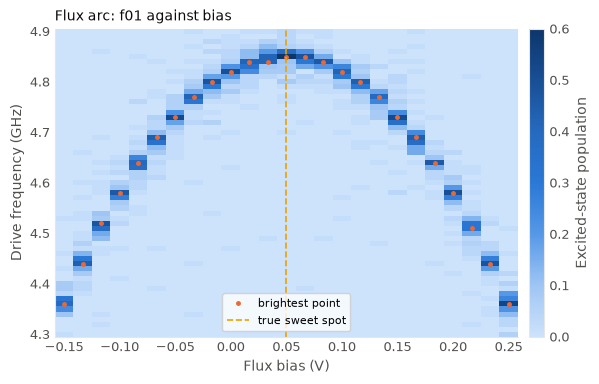

In [22]:
ax = arc_result.plot(
    m_arc,
    field=MF.STATE,
    x="bias",  # bias along the bottom, frequency up the side
    coords={"arc_freq": GHZ},
    value=POPULATION,  # this labels the colour bar rather than an axis
    title="Flux arc: f01 against bias",
)
# The theme's ramp is blue, so the two annotations take warm slots from the same palette and
# stay legible over the map and inside the legend box.
ax.plot(biases, ridge / 1e9, ".", color=LIGHT.series[1], markersize=5, label="brightest point")
ax.axvline(DEVICE["flux_offset"], color=LIGHT.series[3], linestyle="--", linewidth=1.2, label="true sweet spot")
ax.legend(fontsize=8, loc="lower center")
plt.show()

### Fitting the arc

The ridge is quantised to the 10 MHz frequency grid, so no single point in it is better than 10 MHz. The fit comes out much better than any of its inputs, and the reason will come up again. Twenty-five noisy points constrain three parameters, and the symmetry of the arc pins $V_0$ far more tightly than the bias step suggests, because the curve to the left of the maximum and the curve to the right both vote on where the middle is. Fit $f_{\max}$, $V_0$, and $V_\Phi$ and check all three.

A word on the starting guess. The arc is flat at the top and steep at the edges, so a bad guess for the period can land the fit a full period away. Start with $V_0$ at the brightest column and $V_\Phi$ at roughly twice the bias span you scanned.

The figure of the fitted arc is the one plot in this notebook still built by hand, and the reason is worth a sentence. A result knows its own dimensions, its own coordinates, and the units on them, so it can draw itself and label both axes. A curve you computed from three fitted parameters is two numpy arrays and nothing else, so matplotlib stays wherever the data is derived. Count the lines in the cell below that exist only to name an axis and you have the difference.

In [23]:
def arc_model(bias_v, f_max, offset, period):
    """The transmon flux arc: cosine under a square root."""
    return f_max * np.sqrt(np.abs(np.cos(np.pi * (bias_v - offset) / period)))


arc_fit, arc_cov = curve_fit(
    arc_model,
    biases,
    ridge,
    p0=(ridge.max(), float(biases[ridge.argmax()]), 2 * (biases[-1] - biases[0])),
)
f_max_fit, offset_fit, period_fit = arc_fit
arc_sigma = np.sqrt(np.diag(arc_cov))

print(f"f_max  fitted: {f_max_fit / 1e9:.6f} GHz +/- {arc_sigma[0] / 1e6:.3f} MHz")
print(f"f_max  true  : {DEVICE['q0_f01'] / 1e9:.6f} GHz")
print(f"offset fitted: {offset_fit:+.4f} V +/- {arc_sigma[1]:.4f} V")
print(f"offset true  : {DEVICE['flux_offset']:+.4f} V   (bias step was 0.0167 V)")
print(f"period fitted: {period_fit:.4f} V +/- {arc_sigma[2]:.4f} V")
print(f"period true  : {DEVICE['flux_period']:.4f} V")

f_max  fitted: 4.852144 GHz +/- 0.912 MHz
f_max  true  : 4.850000 GHz
offset fitted: +0.0498 V +/- 0.0002 V
offset true  : +0.0500 V   (bias step was 0.0167 V)
period fitted: 0.9978 V +/- 0.0018 V
period true  : 1.0000 V


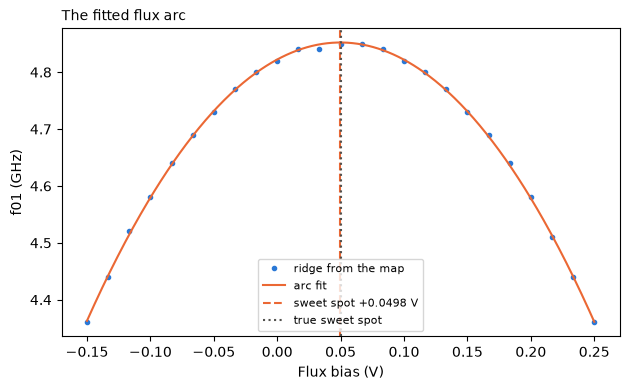

In [24]:
dense_bias = np.linspace(biases[0], biases[-1], 400)

# No result to ask, so the figure, the size, and both axis labels are all typed out here.
fig, ax = plt.subplots(figsize=DEFAULT_SIZE)
ax.plot(biases, ridge / 1e9, ".", color=LIGHT.series[0], label="ridge from the map")
ax.plot(dense_bias, arc_model(dense_bias, *arc_fit) / 1e9, color=LIGHT.series[1], label="arc fit")
ax.axvline(offset_fit, color=LIGHT.series[1], linestyle="--", label=f"sweet spot {offset_fit:+.4f} V")
ax.axvline(DEVICE["flux_offset"], color=LIGHT.muted, linestyle=":", label="true sweet spot")
ax.set_xlabel("Flux bias (V)")
ax.set_ylabel("f01 (GHz)")
ax.set_title("The fitted flux arc", loc="left", fontsize=10, pad=6)
ax.legend(fontsize=8)
plt.show()

### Parking the qubit at a target frequency

The arc is a calibration in both directions. You measured $f_{01}$ against bias, and the useful form is bias against $f_{01}$. Inverting the model gives

$$V = V_0 + \frac{V_\Phi}{\pi} \arccos\!\left( \left( \frac{f_{\text{target}}}{f_{\max}} \right)^{2} \right)$$

and the cell below solves it for 4.70 GHz, then grades itself by feeding the answer back to `f01_of_bias`, the true device.

`arccos` returns one value, but the arc is symmetric about the sweet spot, so two biases give any frequency below $f_{\max}$ and both are printed. Which side you want depends on what else is on the chip. Real chips have neighbours and couplers with their own frequencies, and half the job of choosing a parking spot is staying away from all of them.

In [25]:
f_target = 4.70e9
step = (period_fit / np.pi) * np.arccos((f_target / f_max_fit) ** 2)

for side, bias_solution in (("above the sweet spot", offset_fit + step), ("below", offset_fit - step)):
    print(f"{side:>20}: bias {bias_solution:+.4f} V")
    print(f"{'arc model says':>20}: {arc_model(bias_solution, *arc_fit) / 1e9:.6f} GHz")
    print(f"{'true device gives':>20}: {f01_of_bias(bias_solution) / 1e9:.6f} GHz")
    print(f"{'miss':>20}: {(f01_of_bias(bias_solution) - f_target) / 1e6:+.3f} MHz")

print(f"\ntarget was {f_target / 1e9:.3f} GHz; the two solutions are mirrored about the sweet spot.")

above the sweet spot: bias +0.1620 V
      arc model says: 4.700000 GHz
   true device gives: 4.699046 GHz
                miss: -0.954 MHz
               below: bias -0.0624 V
      arc model says: 4.700000 GHz
   true device gives: 4.698127 GHz
                miss: -1.873 MHz

target was 4.700 GHz; the two solutions are mirrored about the sweet spot.


### One thing to carry into the break

The two `for` loops in the flux arc program are written identically, and on a real rack they are nothing alike. The inner one retunes a microwave source and fires a pulse, which is microseconds per step and belongs inside the sequencer. The outer one writes a DC voltage to a bias source that settles in milliseconds, and on plenty of racks that source is a different instrument with no sequencer in it at all, so the loop has to run host-side.

You never said which was which, and you should not have to. Which loop can run in real time is a property of the rack, not of the experiment. Part 5 hands this exact program to a platform descriptor that reports where each loop landed, warns you when one got demoted to host-side, and offers the rewrite that recovers the real-time averaging you lost.

## Recap and what is next

- **Two-tone spectroscopy** found `f01` to well under a linewidth, by parking on the resonator and watching it move by $2\chi$ when the drive hit resonance. The new mechanism was `fields=(MF.STATE,)`. Ask the measurement for classified outcomes, read them back with `result.get(handle, field=MF.STATE)`, and averaging hands you a population rather than a shot.
- **Rabi in amplitude** turned that frequency into a pi amplitude. The new mechanism was a `Variable` living inside a waveform constructor, so `IQDrag(amplitude=amp, ...)` is one parametric pulse rather than 41 literal ones. The fitted contrast and floor are free diagnostics and worth watching over weeks.
- Fit for the parameter you want, not for a generic curve. `a_pi` and `f01` came out of their fits with their own uncertainties because the models were written in terms of them.
- **Every measured figure came from `result.plot`**, with the fits and the reference lines drawn on the axes it returned. Declaring `label=` and `units=` on a swept variable is what put the words on the x axis, and `Quantity` moved hertz to gigahertz on the drawing without touching the array. The one hand-rolled figure left is the fitted arc, and that is derived data rather than a measurement.
- **The calibrated pulses are objects.** `PI_PULSE` and `X90_PULSE` are `IQDrag` instances with numbers in them and they compare by structure. Part 4 wraps the same shape in a fragment so the amplitude lives in exactly one place.
- **The calibration seam** is the string alias plus `with_waveforms`. The program says `play "pi"` and stays stable across recalibration, and the `WaveformLibrary` carries today's numbers in its own `.wfl` file.
- **The flux arc** put the sweet spot well inside a bias step, and inverting the fitted arc parks the qubit anywhere on the curve you ask for. It was also the first 2D scan whose outer loop steps a slow DC source, written without saying so.

Next: **Part 4, coherence and feedback.** T1, Ramsey, and echo, built out of reusable pulse fragments, then single-shot readout and active reset with a real conditional on a measured state.